# COCO Dataset: Visualization and Bias/Fairness Analysis

This notebook performs comprehensive analysis of the COCO 2017 dataset, including:
1. Dataset exploration and visualization
2. Gender bias analysis in captions
3. Object-gender co-occurrence analysis
4. Caption sentiment and word choice analysis
5. Fairness metrics and recommendations

Based on research from:
- Princeton Visual AI Lab: Understanding and Evaluating Racial Biases in Image Captioning
- UCLA NLP: Men Also Like Shopping - Reducing Gender Bias Amplification
- WWW 2021: Mitigating Gender Bias in Captioning Systems

In [1]:
# Install required packages
!pip install pycocotools matplotlib seaborn pandas numpy pillow wordcloud textblob scikit-learn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import os
import random
from collections import Counter, defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from pycocotools.coco import COCO
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 1. Load COCO Dataset

In [3]:
# Set your paths
BASE_DIR = "/nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/datasets/coco2017"
TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train2017")
VAL_IMG_DIR = os.path.join(BASE_DIR, "val2017")
TRAIN_ANN_FILE = os.path.join(BASE_DIR, "annotations/instances_train2017.json")
VAL_ANN_FILE = os.path.join(BASE_DIR, "annotations/instances_val2017.json")
TRAIN_CAPTION_FILE = os.path.join(BASE_DIR, "annotations/captions_train2017.json")
VAL_CAPTION_FILE = os.path.join(BASE_DIR, "annotations/captions_val2017.json")

print("Loading COCO annotations...")
coco_train = COCO(TRAIN_ANN_FILE)
coco_val = COCO(VAL_ANN_FILE)
coco_train_cap = COCO(TRAIN_CAPTION_FILE)
coco_val_cap = COCO(VAL_CAPTION_FILE)
print("Done!")

Loading COCO annotations...
loading annotations into memory...
Done (t=7.11s)
creating index...
index created!
loading annotations into memory...
Done (t=0.33s)
creating index...
index created!
loading annotations into memory...
Done (t=0.49s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Done!


In [4]:
# Get basic statistics
print(f"Training images: {len(coco_train.imgs)}")
print(f"Validation images: {len(coco_val.imgs)}")
print(f"Training captions: {len(coco_train_cap.anns)}")
print(f"Validation captions: {len(coco_val_cap.anns)}")
print(f"Categories: {len(coco_train.cats)}")

Training images: 118287
Validation images: 5000
Training captions: 591753
Validation captions: 25014
Categories: 80


## 2. Visualize Sample Images with Captions

Sample Training Images with Captions:


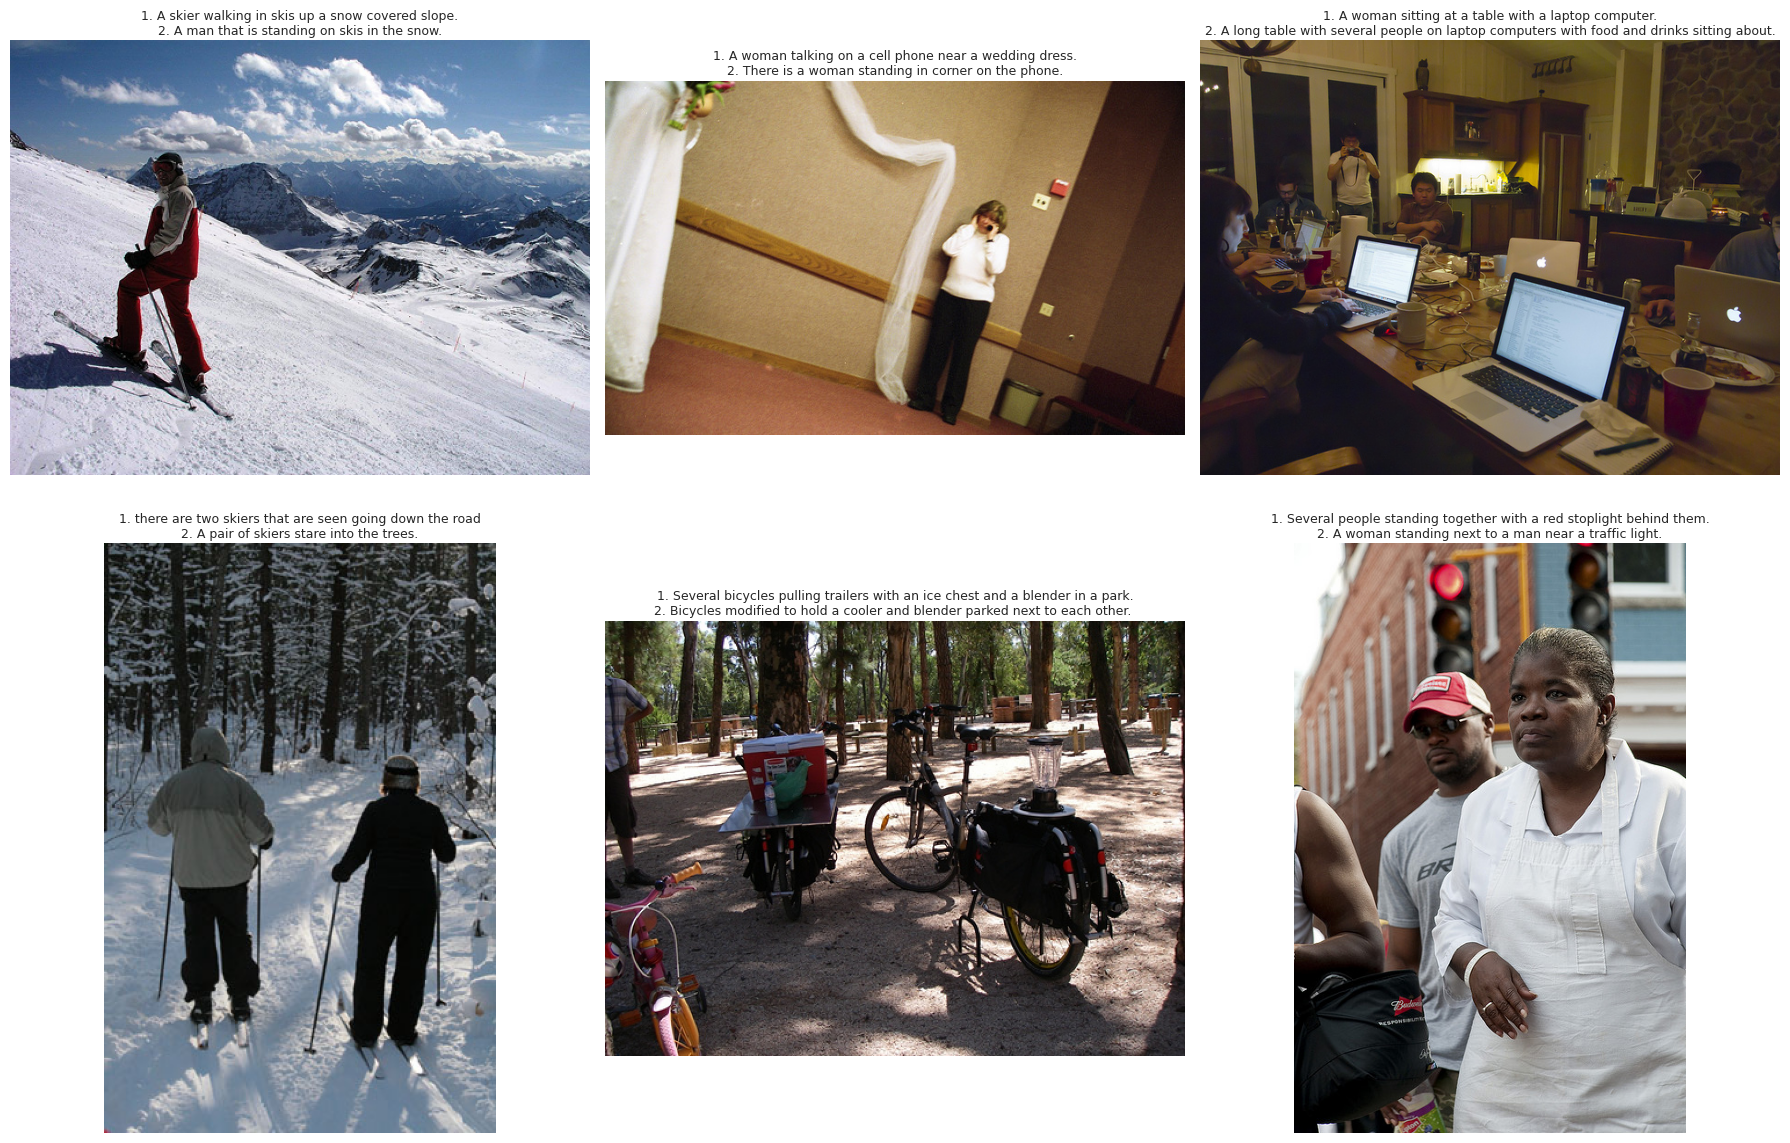

In [5]:
def visualize_images_with_captions(coco_obj, coco_cap, img_dir, num_images=6):
    """Display random images with their captions"""
    img_ids = random.sample(list(coco_obj.imgs.keys()), num_images)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.ravel()
    
    for idx, img_id in enumerate(img_ids):
        img_info = coco_obj.imgs[img_id]
        img_path = os.path.join(img_dir, img_info['file_name'])
        
        # Load and display image
        img = Image.open(img_path)
        axes[idx].imshow(img)
        axes[idx].axis('off')
        
        # Get captions
        ann_ids = coco_cap.getAnnIds(imgIds=img_id)
        anns = coco_cap.loadAnns(ann_ids)
        captions = [ann['caption'] for ann in anns[:2]]  # Show first 2 captions
        
        caption_text = '\n'.join([f"{i+1}. {cap}" for i, cap in enumerate(captions)])
        axes[idx].set_title(caption_text, fontsize=9, wrap=True)
    
    plt.tight_layout()
    plt.savefig('sample_images_captions.png', dpi=150, bbox_inches='tight')
    plt.show()

print("Sample Training Images with Captions:")
visualize_images_with_captions(coco_train, coco_train_cap, TRAIN_IMG_DIR)

## 3. Extract and Analyze Gender Information from Captions

In [6]:
# Define gender-related terms
MALE_TERMS = ['man', 'men', 'male', 'boy', 'boys', 'guy', 'guys', 'gentleman', 
              'he', 'him', 'his', 'father', 'dad', 'son', 'brother', 'husband',
              'boyfriend', 'grandfather', 'uncle', 'nephew']

FEMALE_TERMS = ['woman', 'women', 'female', 'girl', 'girls', 'lady', 'ladies', 
                'she', 'her', 'hers', 'mother', 'mom', 'daughter', 'sister', 'wife',
                'girlfriend', 'grandmother', 'aunt', 'niece']

def extract_gender_from_caption(caption):
    """Extract gender information from caption"""
    caption_lower = caption.lower()
    
    has_male = any(term in caption_lower for term in MALE_TERMS)
    has_female = any(term in caption_lower for term in FEMALE_TERMS)
    
    if has_male and has_female:
        return 'both'
    elif has_male:
        return 'male'
    elif has_female:
        return 'female'
    else:
        return 'neutral'

def analyze_gender_distribution(coco_cap):
    """Analyze gender distribution in captions"""
    gender_counts = {'male': 0, 'female': 0, 'both': 0, 'neutral': 0}
    
    for ann_id in coco_cap.anns:
        caption = coco_cap.anns[ann_id]['caption']
        gender = extract_gender_from_caption(caption)
        gender_counts[gender] += 1
    
    return gender_counts

print("Analyzing gender distribution in captions...")
train_gender = analyze_gender_distribution(coco_train_cap)
val_gender = analyze_gender_distribution(coco_val_cap)

print("\nTraining Set Gender Distribution:")
for gender, count in train_gender.items():
    print(f"  {gender.capitalize()}: {count:,} ({count/sum(train_gender.values())*100:.2f}%)")

print("\nValidation Set Gender Distribution:")
for gender, count in val_gender.items():
    print(f"  {gender.capitalize()}: {count:,} ({count/sum(val_gender.values())*100:.2f}%)")

Analyzing gender distribution in captions...

Training Set Gender Distribution:
  Male: 253,082 (42.77%)
  Female: 6,307 (1.07%)
  Both: 103,955 (17.57%)
  Neutral: 228,409 (38.60%)

Validation Set Gender Distribution:
  Male: 10,620 (42.46%)
  Female: 255 (1.02%)
  Both: 4,325 (17.29%)
  Neutral: 9,814 (39.23%)


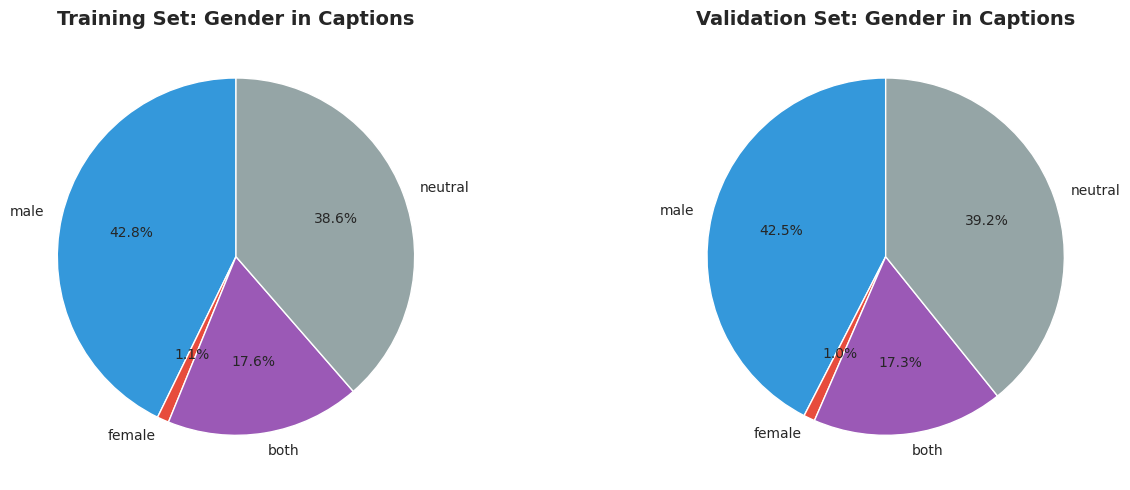


⚠️ Male-to-Female Ratio in Training Set: 3.24:1


In [7]:
# Visualize gender distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training set
colors = ['#3498db', '#e74c3c', '#9b59b6', '#95a5a6']
axes[0].pie(train_gender.values(), labels=train_gender.keys(), autopct='%1.1f%%',
            startangle=90, colors=colors)
axes[0].set_title('Training Set: Gender in Captions', fontsize=14, fontweight='bold')

# Validation set
axes[1].pie(val_gender.values(), labels=val_gender.keys(), autopct='%1.1f%%',
            startangle=90, colors=colors)
axes[1].set_title('Validation Set: Gender in Captions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Calculate male-to-female ratio
male_count = train_gender['male'] + train_gender['both']
female_count = train_gender['female'] + train_gender['both']
ratio = male_count / female_count if female_count > 0 else 0
print(f"\n⚠️ Male-to-Female Ratio in Training Set: {ratio:.2f}:1")
if ratio > 1.5:
    print("   WARNING: Significant gender imbalance detected!")

## 4. Object-Gender Co-occurrence Analysis

This analysis examines which objects are frequently associated with specific genders in captions, revealing potential stereotypical associations.

In [8]:
# Cell: Corrected Object-Gender Co-occurrence Analysis

def analyze_object_gender_cooccurrence_corrected(coco_obj, coco_cap):
    """Analyze which objects co-occur with male vs female mentions (CORRECTED VERSION)"""
    # Get category names
    categories = {cat_id: coco_obj.cats[cat_id]['name'] 
                  for cat_id in coco_obj.cats}
    
    object_gender_counts = defaultdict(lambda: {'male': 0, 'female': 0, 'neutral': 0})
    
    # Track total images by gender
    total_gender_images = {'male': 0, 'female': 0, 'neutral': 0}
    
    for img_id in coco_obj.imgs:
        # Get objects in image
        ann_ids = coco_obj.getAnnIds(imgIds=img_id)
        anns = coco_obj.loadAnns(ann_ids)
        objects_in_image = set([categories[ann['category_id']] for ann in anns])
        
        # Get captions for image
        cap_ids = coco_cap.getAnnIds(imgIds=img_id)
        caps = coco_cap.loadAnns(cap_ids)
        
        # Determine predominant gender in captions
        gender_votes = [extract_gender_from_caption(cap['caption']) for cap in caps]
        gender_counts = Counter(gender_votes)
        
        # Skip 'both' and assign based on majority
        if gender_counts['male'] > gender_counts['female']:
            predominant_gender = 'male'
        elif gender_counts['female'] > gender_counts['male']:
            predominant_gender = 'female'
        else:
            predominant_gender = 'neutral'
        
        # Count this image towards the gender total
        total_gender_images[predominant_gender] += 1
        
        # Update counts for each object
        for obj in objects_in_image:
            object_gender_counts[obj][predominant_gender] += 1
    
    return object_gender_counts, total_gender_images

print("Analyzing object-gender co-occurrence (this may take a few minutes)...")
object_gender_data, total_images_by_gender = analyze_object_gender_cooccurrence_corrected(coco_train, coco_train_cap)
print("Done!")

print(f"\nTotal images by gender:")
print(f"  Male: {total_images_by_gender['male']:,}")
print(f"  Female: {total_images_by_gender['female']:,}")
print(f"  Neutral: {total_images_by_gender['neutral']:,}")
print(f"  Male-to-Female Image Ratio: {total_images_by_gender['male']/total_images_by_gender['female']:.2f}:1")

Analyzing object-gender co-occurrence (this may take a few minutes)...
Done!

Total images by gender:
  Male: 94,225
  Female: 2,962
  Neutral: 21,100
  Male-to-Female Image Ratio: 31.81:1


In [9]:
# Cell: Calculate Corrected Gender Bias Scores

def calculate_gender_bias_score_corrected(obj_data, total_images):
    """Calculate bias score using rates: (m/M - f/F) or (m/M) / (f/F)"""
    male = obj_data['male']
    female = obj_data['female']
    
    M = total_images['male']
    F = total_images['female']
    
    # Require minimum occurrences
    if male + female < 50:
        return None
    
    # Calculate rates
    male_rate = male / M if M > 0 else 0
    female_rate = female / F if F > 0 else 0
    
    # Calculate bias score as difference in rates
    # Positive = male-associated, Negative = female-associated
    bias_score_diff = male_rate - female_rate
    
    # Also calculate ratio (how many times more likely in male vs female images)
    if female_rate > 0:
        bias_ratio = male_rate / female_rate
    else:
        bias_ratio = float('inf') if male_rate > 0 else 1.0
    
    return {
        'bias_score_diff': bias_score_diff,
        'bias_ratio': bias_ratio,
        'male_rate': male_rate * 100,  # Convert to percentage
        'female_rate': female_rate * 100,
        'male_count': male,
        'female_count': female
    }

# Calculate corrected bias scores
object_bias_corrected = {}
for obj, data in object_gender_data.items():
    bias = calculate_gender_bias_score_corrected(data, total_images_by_gender)
    if bias is not None:
        total = data['male'] + data['female'] + data['neutral']
        object_bias_corrected[obj] = {
            'bias_score_diff': bias['bias_score_diff'],
            'bias_ratio': bias['bias_ratio'],
            'male_rate': bias['male_rate'],
            'female_rate': bias['female_rate'],
            'male_count': bias['male_count'],
            'female_count': bias['female_count'],
            'total': total
        }

# Sort by bias ratio
sorted_bias_corrected = sorted(object_bias_corrected.items(), 
                               key=lambda x: x[1]['bias_ratio'], 
                               reverse=True)

print("\n=== Top 10 Male-Associated Objects (Corrected) ===")
print(f"{'Object':<20} {'Ratio':>8} {'Male Rate':>10} {'Female Rate':>12} {'Counts':>15}")
print("-" * 70)
for obj, data in sorted_bias_corrected[:10]:
    if data['bias_ratio'] != float('inf'):
        print(f"{obj:<20} {data['bias_ratio']:>7.2f}x {data['male_rate']:>9.2f}% {data['female_rate']:>11.2f}% "
              f"(M:{data['male_count']}, F:{data['female_count']})")

print("\n=== Top 10 Female-Associated Objects (Corrected) ===")
print(f"{'Object':<20} {'Ratio':>8} {'Male Rate':>10} {'Female Rate':>12} {'Counts':>15}")
print("-" * 70)
for obj, data in sorted_bias_corrected[-10:][::-1]:
    print(f"{obj:<20} {data['bias_ratio']:>7.2f}x {data['male_rate']:>9.2f}% {data['female_rate']:>11.2f}% "
          f"(M:{data['male_count']}, F:{data['female_count']})")


=== Top 10 Male-Associated Objects (Corrected) ===
Object                  Ratio  Male Rate  Female Rate          Counts
----------------------------------------------------------------------
bear                   13.17x      0.89%        0.07% (M:838, F:2)
airplane               10.89x      2.94%        0.27% (M:2772, F:8)
train                  10.07x      3.40%        0.34% (M:3202, F:10)
zebra                   7.70x      1.56%        0.20% (M:1469, F:6)
traffic light           5.16x      3.84%        0.74% (M:3614, F:22)
snowboard               4.15x      1.68%        0.41% (M:1583, F:12)
boat                    3.99x      2.96%        0.74% (M:2790, F:22)
bird                    3.90x      3.03%        0.78% (M:2853, F:23)
bus                     3.24x      3.61%        1.11% (M:3406, F:33)
parking meter           3.04x      0.62%        0.20% (M:580, F:6)

=== Top 10 Female-Associated Objects (Corrected) ===
Object                  Ratio  Male Rate  Female Rate          Counts

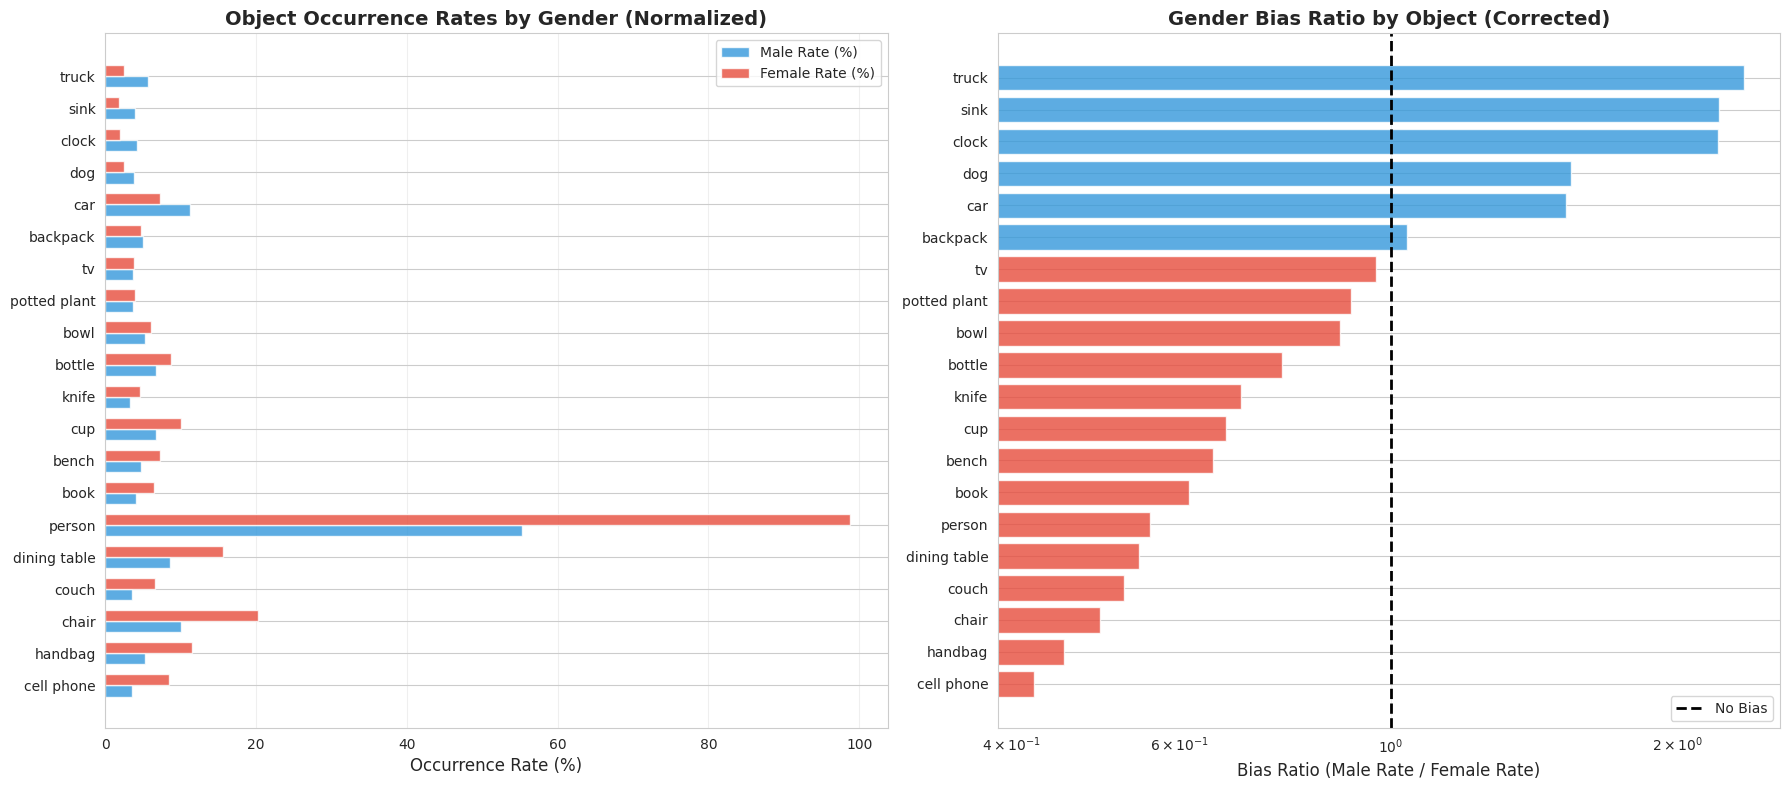


📊 Interpretation:
- Bias Ratio > 1: Object appears MORE in male images (relative to base rate)
- Bias Ratio < 1: Object appears MORE in female images (relative to base rate)
- Bias Ratio = 1: No gender association (appears equally in both)


In [10]:
# Cell: Visualize Corrected Object-Gender Associations

# Select top objects by total count for visualization
top_objects_corrected = sorted(object_bias_corrected.items(), 
                               key=lambda x: x[1]['total'], 
                               reverse=True)[:20]
top_objects_corrected = sorted(top_objects_corrected, 
                               key=lambda x: x[1]['bias_ratio'])

objects = [obj for obj, _ in top_objects_corrected]
male_rates = [data['male_rate'] for _, data in top_objects_corrected]
female_rates = [data['female_rate'] for _, data in top_objects_corrected]
bias_ratios = [data['bias_ratio'] for _, data in top_objects_corrected]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Rate comparison
y_pos = np.arange(len(objects))
width = 0.35

ax1.barh(y_pos - width/2, male_rates, width, label='Male Rate (%)', 
         color='#3498db', alpha=0.8)
ax1.barh(y_pos + width/2, female_rates, width, label='Female Rate (%)', 
         color='#e74c3c', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(objects)
ax1.set_xlabel('Occurrence Rate (%)', fontsize=12)
ax1.set_title('Object Occurrence Rates by Gender (Normalized)', 
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Bias ratio visualization
colors = ['#e74c3c' if ratio < 1 else '#3498db' for ratio in bias_ratios]
ax2.barh(y_pos, bias_ratios, color=colors, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(objects)
ax2.set_xlabel('Bias Ratio (Male Rate / Female Rate)', fontsize=12)
ax2.set_title('Gender Bias Ratio by Object (Corrected)', 
              fontsize=14, fontweight='bold')
ax2.axvline(x=1, color='black', linestyle='--', linewidth=2, label='No Bias')
ax2.set_xscale('log')  # Log scale since ratios can be very large
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('object_gender_bias_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Interpretation:")
print("- Bias Ratio > 1: Object appears MORE in male images (relative to base rate)")
print("- Bias Ratio < 1: Object appears MORE in female images (relative to base rate)")
print("- Bias Ratio = 1: No gender association (appears equally in both)")

## 5. Caption Word Analysis

Analyze word usage patterns in captions containing gender references.

In [11]:
# Cell: Corrected Caption Word Analysis

from collections import Counter
import re

def extract_words_by_gender_corrected(coco_cap, gender_type='male'):
    """Extract words from captions of a specific gender type"""
    words = []
    caption_count = 0  # Track total captions of this gender
    
    for ann_id in coco_cap.anns:
        caption = coco_cap.anns[ann_id]['caption']
        gender = extract_gender_from_caption(caption)
        
        if gender == gender_type:
            caption_count += 1
            # Tokenize and clean
            caption_words = re.findall(r'\b[a-z]+\b', caption.lower())
            # Remove gender terms and common stop words
            stop_words = set(MALE_TERMS + FEMALE_TERMS + 
                           ['the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for',
                            'of', 'with', 'by', 'from', 'is', 'are', 'was', 'were', 'be', 'been'])
            caption_words = [w for w in caption_words if w not in stop_words and len(w) > 2]
            words.extend(caption_words)
    
    return Counter(words), caption_count

print("Extracting words from gender-specific captions...")
male_words, total_male_captions = extract_words_by_gender_corrected(coco_train_cap, 'male')
female_words, total_female_captions = extract_words_by_gender_corrected(coco_train_cap, 'female')
neutral_words, total_neutral_captions = extract_words_by_gender_corrected(coco_train_cap, 'neutral')
print("Done!")

print(f"\nTotal captions by gender:")
print(f"  Male: {total_male_captions:,}")
print(f"  Female: {total_female_captions:,}")
print(f"  Neutral: {total_neutral_captions:,}")
print(f"  Male-to-Female Caption Ratio: {total_male_captions/total_female_captions:.2f}:1")

print("\nTop 20 words in male-associated captions:")
for word, count in male_words.most_common(20):
    rate = count / total_male_captions * 100
    print(f"  {word:15s}: {count:,} ({rate:.2f}% of male captions)")

print("\nTop 20 words in female-associated captions:")
for word, count in female_words.most_common(20):
    rate = count / total_female_captions * 100
    print(f"  {word:15s}: {count:,} ({rate:.2f}% of female captions)")

Extracting words from gender-specific captions...
Done!

Total captions by gender:
  Male: 253,082
  Female: 6,307
  Neutral: 228,409
  Male-to-Female Caption Ratio: 40.13:1

Top 20 words in male-associated captions:
  person         : 23,104 (9.13% of male captions)
  sitting        : 18,434 (7.28% of male captions)
  two            : 17,732 (7.01% of male captions)
  standing       : 17,460 (6.90% of male captions)
  people         : 14,982 (5.92% of male captions)
  holding        : 14,478 (5.72% of male captions)
  street         : 13,415 (5.30% of male captions)
  riding         : 12,728 (5.03% of male captions)
  down           : 12,388 (4.89% of male captions)
  white          : 11,157 (4.41% of male captions)
  kitchen        : 10,809 (4.27% of male captions)
  that           : 10,665 (4.21% of male captions)
  tennis         : 10,198 (4.03% of male captions)
  next           : 9,739 (3.85% of male captions)
  water          : 9,485 (3.75% of male captions)
  young          : 9

In [12]:
# Cell: Calculate Corrected Word-Gender Ratios

def calculate_word_gender_ratio_corrected(male_words, female_words, 
                                          total_male_captions, total_female_captions,
                                          min_count=100):
    """Calculate ratio of male to female occurrence rates for each word"""
    all_words = set(male_words.keys()) | set(female_words.keys())
    
    word_ratios = []
    for word in all_words:
        male_count = male_words.get(word, 0)
        female_count = female_words.get(word, 0)
        total = male_count + female_count
        
        if total >= min_count:
            # Calculate rates (percentage of captions containing this word)
            male_rate = (male_count / total_male_captions) * 100
            female_rate = (female_count / total_female_captions) * 100
            
            # Calculate ratio of rates
            if female_rate > 0:
                ratio = male_rate / female_rate
            else:
                ratio = float('inf')
            
            # Calculate difference in rates
            rate_diff = male_rate - female_rate
            
            word_ratios.append({
                'word': word,
                'male_count': male_count,
                'female_count': female_count,
                'male_rate': male_rate,
                'female_rate': female_rate,
                'ratio': ratio,
                'rate_diff': rate_diff,
                'total': total
            })
    
    return word_ratios

word_ratios_corrected = calculate_word_gender_ratio_corrected(
    male_words, female_words, 
    total_male_captions, total_female_captions
)
word_ratios_sorted = sorted(word_ratios_corrected, key=lambda x: x['ratio'], reverse=True)

print("\n=== Words Most Associated with Males (Corrected) ===")
print(f"{'Word':<15} {'Ratio':>8} {'Male Rate':>10} {'Female Rate':>12} {'Counts':>20}")
print("-" * 70)
for item in word_ratios_sorted[:15]:
    if item['ratio'] != float('inf'):
        print(f"{item['word']:<15} {item['ratio']:>7.2f}x {item['male_rate']:>9.2f}% {item['female_rate']:>11.2f}% "
              f"(M:{item['male_count']}, F:{item['female_count']})")

print("\n=== Words Most Associated with Females (Corrected) ===")
print(f"{'Word':<15} {'Ratio':>8} {'Male Rate':>10} {'Female Rate':>12} {'Counts':>20}")
print("-" * 70)
for item in word_ratios_sorted[-15:][::-1]:
    print(f"{item['word']:<15} {item['ratio']:>7.2f}x {item['male_rate']:>9.2f}% {item['female_rate']:>11.2f}% "
          f"(M:{item['male_count']}, F:{item['female_count']})")


=== Words Most Associated with Males (Corrected) ===
Word               Ratio  Male Rate  Female Rate               Counts
----------------------------------------------------------------------

=== Words Most Associated with Females (Corrected) ===
Word               Ratio  Male Rate  Female Rate               Counts
----------------------------------------------------------------------
pretty             0.03x      0.07%        2.66% (M:187, F:168)
blonde             0.04x      0.02%        0.65% (M:63, F:41)
little             0.05x      0.94%       19.20% (M:2368, F:1211)
dress              0.05x      0.11%        2.22% (M:290, F:140)
beautiful          0.08x      0.12%        1.43% (M:297, F:90)
cute               0.08x      0.10%        1.17% (M:245, F:74)
pink               0.09x      0.32%        3.77% (M:822, F:238)
doll               0.11x      0.04%        0.35% (M:96, F:22)
haired             0.13x      0.04%        0.30% (M:98, F:19)
petting            0.14x      0.06%   

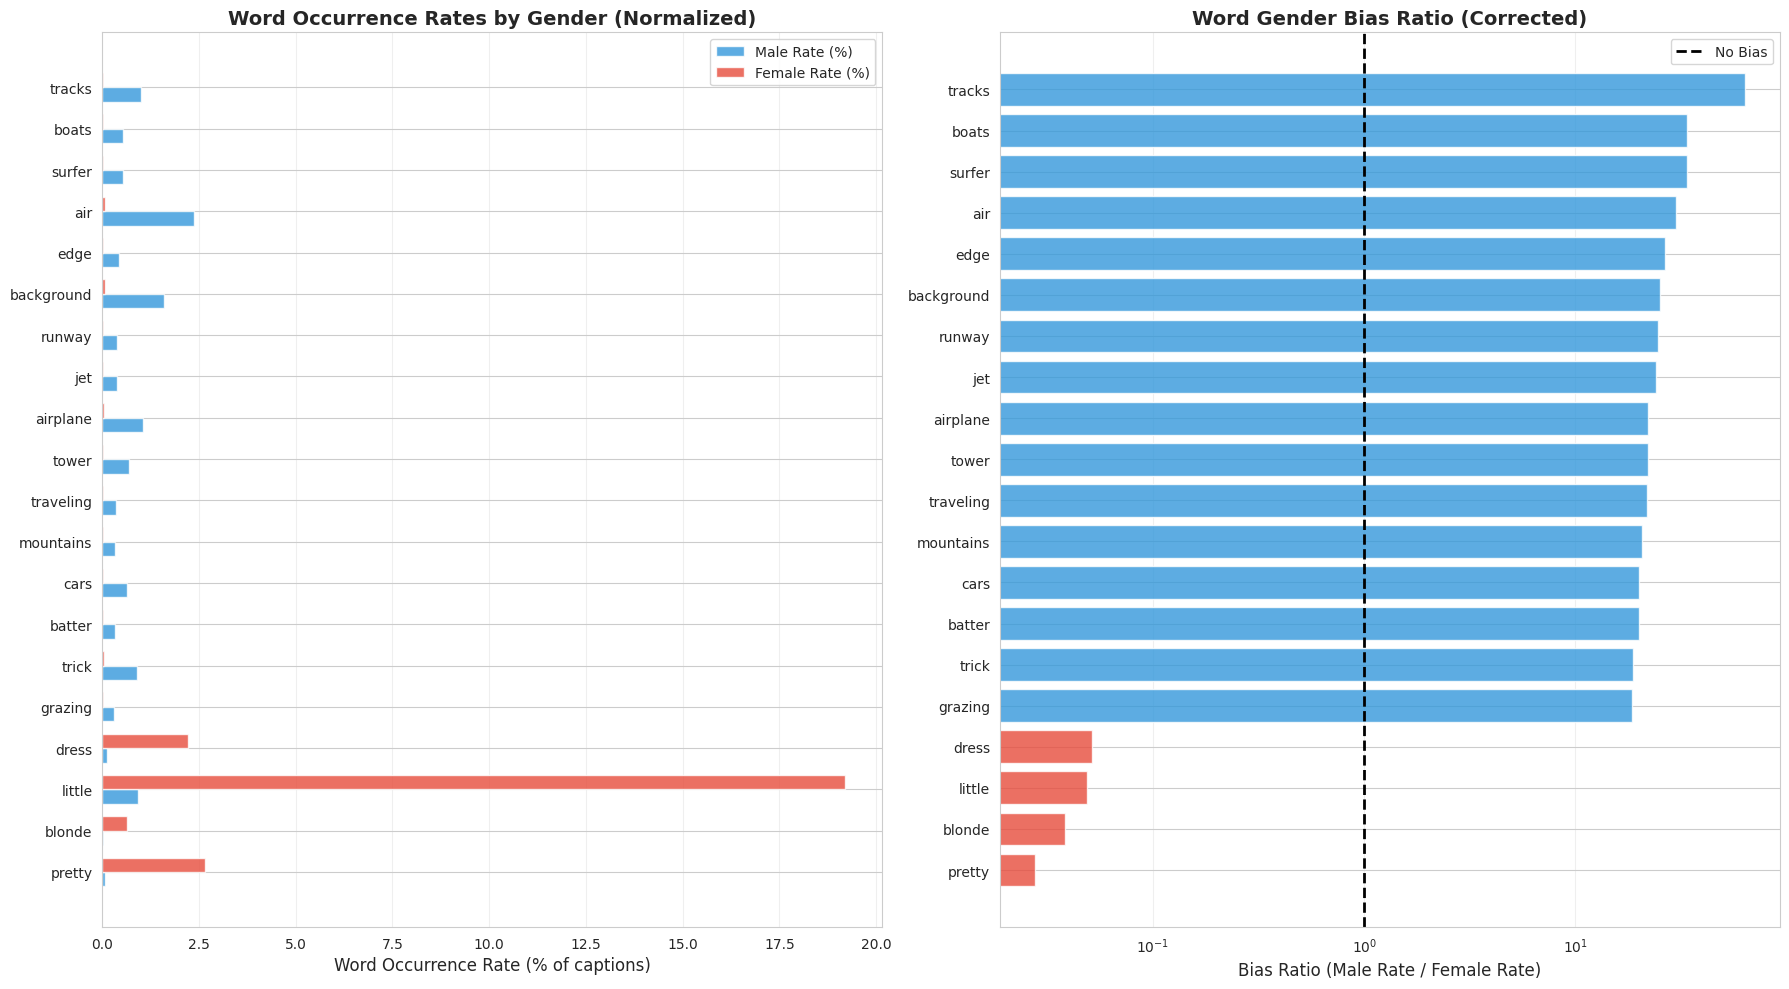


📊 Interpretation:
- Ratio > 1: Word appears MORE in male captions (relative to base rate)
- Ratio < 1: Word appears MORE in female captions (relative to base rate)
- Ratio = 1: No gender association


In [13]:
# Cell: Visualize Word-Gender Associations

# Select words with strongest bias (by ratio)
top_biased_words = sorted(word_ratios_corrected, 
                          key=lambda x: abs(np.log(x['ratio']) if x['ratio'] != float('inf') else 0), 
                          reverse=True)[:20]
top_biased_words = sorted(top_biased_words, key=lambda x: x['ratio'])

words = [item['word'] for item in top_biased_words]
male_rates = [item['male_rate'] for item in top_biased_words]
female_rates = [item['female_rate'] for item in top_biased_words]
ratios = [item['ratio'] for item in top_biased_words]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# Rate comparison
y_pos = np.arange(len(words))
width = 0.35

ax1.barh(y_pos - width/2, male_rates, width, label='Male Rate (%)', 
         color='#3498db', alpha=0.8)
ax1.barh(y_pos + width/2, female_rates, width, label='Female Rate (%)', 
         color='#e74c3c', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(words)
ax1.set_xlabel('Word Occurrence Rate (% of captions)', fontsize=12)
ax1.set_title('Word Occurrence Rates by Gender (Normalized)', 
              fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(axis='x', alpha=0.3)

# Bias ratio visualization
colors = ['#e74c3c' if ratio < 1 else '#3498db' for ratio in ratios]
ratios_plot = [r if r != float('inf') else max([r for r in ratios if r != float('inf')]) * 2 
               for r in ratios]
ax2.barh(y_pos, ratios_plot, color=colors, alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(words)
ax2.set_xlabel('Bias Ratio (Male Rate / Female Rate)', fontsize=12)
ax2.set_title('Word Gender Bias Ratio (Corrected)', 
              fontsize=14, fontweight='bold')
ax2.axvline(x=1, color='black', linestyle='--', linewidth=2, label='No Bias')
ax2.set_xscale('log')
ax2.legend()
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('word_gender_bias_corrected.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Interpretation:")
print("- Ratio > 1: Word appears MORE in male captions (relative to base rate)")
print("- Ratio < 1: Word appears MORE in female captions (relative to base rate)")
print("- Ratio = 1: No gender association")

## 6. Activity-Gender Association Analysis

Examine which activities/actions are associated with different genders.

In [14]:
# Cell: Corrected Activity-Gender Association Analysis

# Define activity-related verbs
ACTIVITY_VERBS = [
    'playing', 'cooking', 'surfing', 'skiing', 'skateboarding', 'snowboarding',
    'riding', 'driving', 'flying', 'running', 'walking', 'sitting', 'standing',
    'jumping', 'throwing', 'catching', 'holding', 'carrying', 'eating', 'drinking',
    'reading', 'writing', 'talking', 'smiling', 'laughing', 'working', 'shopping',
    'dancing', 'singing', 'painting', 'drawing', 'cleaning', 'washing', 'cutting'
]

def analyze_activity_gender_association_corrected(coco_cap):
    """Analyze which activities are associated with which genders (CORRECTED)"""
    activity_gender = defaultdict(lambda: {'male': 0, 'female': 0})
    
    # Track total captions by gender
    total_captions_by_gender = {'male': 0, 'female': 0}
    
    for ann_id in coco_cap.anns:
        caption = coco_cap.anns[ann_id]['caption']
        caption_lower = caption.lower()
        gender = extract_gender_from_caption(caption)
        
        if gender in ['male', 'female']:
            total_captions_by_gender[gender] += 1
            
            for activity in ACTIVITY_VERBS:
                if activity in caption_lower:
                    activity_gender[activity][gender] += 1
    
    return activity_gender, total_captions_by_gender

print("Analyzing activity-gender associations...")
activity_data, total_captions_by_gender = analyze_activity_gender_association_corrected(coco_train_cap)

print(f"\nTotal captions by gender (for activity analysis):")
print(f"  Male: {total_captions_by_gender['male']:,}")
print(f"  Female: {total_captions_by_gender['female']:,}")

# Calculate corrected ratios and filter
activity_analysis_corrected = []
for activity, counts in activity_data.items():
    total = counts['male'] + counts['female']
    if total >= 50:  # Minimum threshold
        # Calculate rates (percentage of gender-specific captions with this activity)
        male_rate = (counts['male'] / total_captions_by_gender['male']) * 100
        female_rate = (counts['female'] / total_captions_by_gender['female']) * 100
        
        # Calculate ratio
        if female_rate > 0:
            bias_ratio = male_rate / female_rate
        else:
            bias_ratio = float('inf')
        
        # Calculate difference in rates
        rate_diff = male_rate - female_rate
        
        activity_analysis_corrected.append({
            'activity': activity,
            'male_count': counts['male'],
            'female_count': counts['female'],
            'male_rate': male_rate,
            'female_rate': female_rate,
            'bias_ratio': bias_ratio,
            'rate_diff': rate_diff,
            'total': total
        })

# Sort by bias ratio
activity_analysis_corrected.sort(key=lambda x: x['bias_ratio'], reverse=True)

print("\n=== Activities Most Associated with Males (Corrected) ===")
print(f"{'Activity':<15} {'Ratio':>8} {'Male Rate':>10} {'Female Rate':>12} {'Counts':>20}")
print("-" * 75)
for item in activity_analysis_corrected[:10]:
    if item['bias_ratio'] != float('inf'):
        print(f"{item['activity']:<15} {item['bias_ratio']:>7.2f}x {item['male_rate']:>9.3f}% {item['female_rate']:>11.3f}% "
              f"(M:{item['male_count']}, F:{item['female_count']})")

print("\n=== Activities Most Associated with Females (Corrected) ===")
print(f"{'Activity':<15} {'Ratio':>8} {'Male Rate':>10} {'Female Rate':>12} {'Counts':>20}")
print("-" * 75)
for item in activity_analysis_corrected[-10:][::-1]:
    print(f"{item['activity']:<15} {item['bias_ratio']:>7.2f}x {item['male_rate']:>9.3f}% {item['female_rate']:>11.3f}% "
          f"(M:{item['male_count']}, F:{item['female_count']})")

Analyzing activity-gender associations...

Total captions by gender (for activity analysis):
  Male: 253,082
  Female: 6,307

=== Activities Most Associated with Males (Corrected) ===
Activity           Ratio  Male Rate  Female Rate               Counts
---------------------------------------------------------------------------
surfing            3.31x     0.683%       0.206% (M:1729, F:13)
cooking            3.25x     0.206%       0.063% (M:522, F:4)
snowboarding       2.72x     0.172%       0.063% (M:436, F:4)
skateboarding      2.33x     0.370%       0.159% (M:936, F:10)
jumping            1.78x     0.906%       0.507% (M:2292, F:32)
riding             1.42x     5.016%       3.520% (M:12694, F:222)
skiing             1.37x     0.846%       0.618% (M:2140, F:39)
washing            1.36x     0.065%       0.048% (M:164, F:3)
working            1.32x     0.293%       0.222% (M:742, F:14)

=== Activities Most Associated with Females (Corrected) ===
Activity           Ratio  Male Rate  Fe

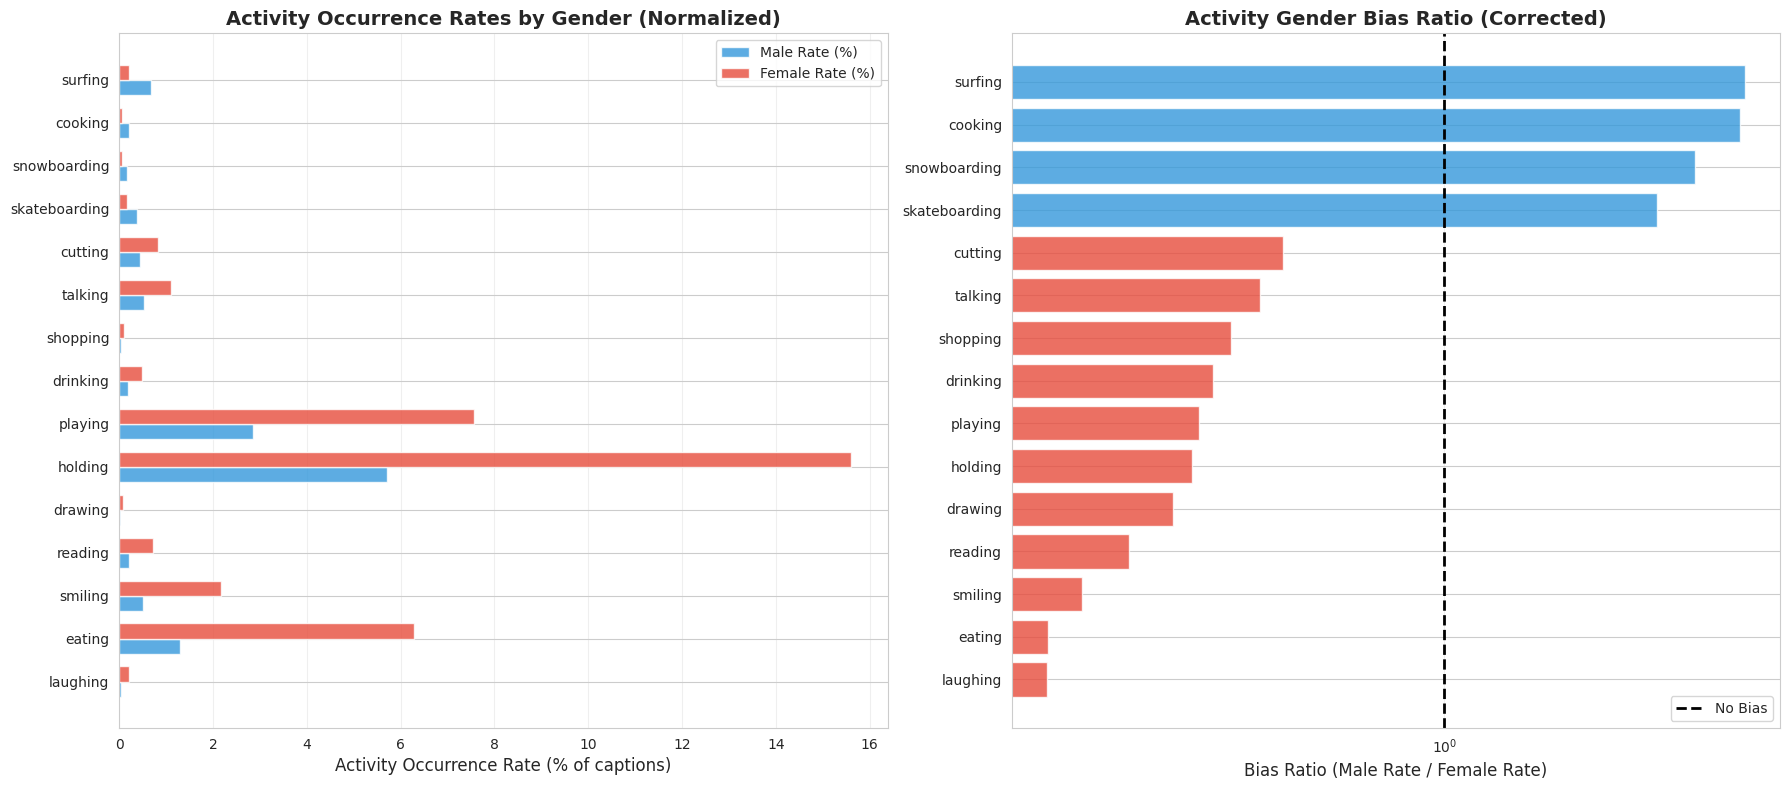


📊 Interpretation:
- Ratio > 1: Activity appears MORE in male captions (relative to base rate)
- Ratio < 1: Activity appears MORE in female captions (relative to base rate)
- Ratio = 1: No gender association


In [15]:
# Cell: Visualize Corrected Activity-Gender Associations

if len(activity_analysis_corrected) > 0:
    # Select activities with strongest bias in either direction
    sorted_activities = sorted(activity_analysis_corrected, 
                              key=lambda x: abs(np.log(x['bias_ratio']) if x['bias_ratio'] != float('inf') else 0), 
                              reverse=True)[:15]
    sorted_activities = sorted(sorted_activities, key=lambda x: x['bias_ratio'])
    
    activities = [item['activity'] for item in sorted_activities]
    male_rates = [item['male_rate'] for item in sorted_activities]
    female_rates = [item['female_rate'] for item in sorted_activities]
    bias_ratios = [item['bias_ratio'] for item in sorted_activities]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    y_pos = np.arange(len(activities))
    width = 0.35
    
    # Rate comparison
    ax1.barh(y_pos - width/2, male_rates, width, label='Male Rate (%)', 
             color='#3498db', alpha=0.8)
    ax1.barh(y_pos + width/2, female_rates, width, label='Female Rate (%)', 
             color='#e74c3c', alpha=0.8)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(activities)
    ax1.set_xlabel('Activity Occurrence Rate (% of captions)', fontsize=12)
    ax1.set_title('Activity Occurrence Rates by Gender (Normalized)', 
                  fontsize=14, fontweight='bold')
    ax1.legend()
    ax1.grid(axis='x', alpha=0.3)
    
    # Bias ratio visualization
    colors = ['#e74c3c' if ratio < 1 else '#3498db' for ratio in bias_ratios]
    ratios_plot = [r if r != float('inf') else max([r for r in bias_ratios if r != float('inf')]) * 2 
                   for r in bias_ratios]
    ax2.barh(y_pos, ratios_plot, color=colors, alpha=0.8)
    ax2.set_yticks(y_pos)
    ax2.set_yticklabels(activities)
    ax2.set_xlabel('Bias Ratio (Male Rate / Female Rate)', fontsize=12)
    ax2.set_title('Activity Gender Bias Ratio (Corrected)', 
                  fontsize=14, fontweight='bold')
    ax2.axvline(x=1, color='black', linestyle='--', linewidth=2, label='No Bias')
    ax2.set_xscale('log')
    ax2.legend()
    ax2.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('activity_gender_bias_corrected.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n📊 Interpretation:")
    print("- Ratio > 1: Activity appears MORE in male captions (relative to base rate)")
    print("- Ratio < 1: Activity appears MORE in female captions (relative to base rate)")
    print("- Ratio = 1: No gender association")

## 7. Caption Length and Complexity Analysis by Gender

In [16]:
def analyze_caption_characteristics(coco_cap):
    """Analyze caption length and complexity by gender"""
    gender_captions = {'male': [], 'female': [], 'neutral': []}
    
    for ann_id in coco_cap.anns:
        caption = coco_cap.anns[ann_id]['caption']
        gender = extract_gender_from_caption(caption)
        
        if gender != 'both':
            word_count = len(caption.split())
            char_count = len(caption)
            gender_captions[gender].append({
                'word_count': word_count,
                'char_count': char_count,
                'caption': caption
            })
    
    return gender_captions

print("Analyzing caption characteristics...")
caption_data = analyze_caption_characteristics(coco_train_cap)

# Calculate statistics
stats = {}
for gender, captions in caption_data.items():
    if len(captions) > 0:
        word_counts = [c['word_count'] for c in captions]
        stats[gender] = {
            'mean_words': np.mean(word_counts),
            'median_words': np.median(word_counts),
            'std_words': np.std(word_counts),
            'count': len(captions)
        }

print("\nCaption Length Statistics by Gender:")
for gender, stat in stats.items():
    print(f"\n{gender.upper()}:")
    print(f"  Count: {stat['count']:,}")
    print(f"  Mean words: {stat['mean_words']:.2f}")
    print(f"  Median words: {stat['median_words']:.1f}")
    print(f"  Std dev: {stat['std_words']:.2f}")

Analyzing caption characteristics...

Caption Length Statistics by Gender:

MALE:
  Count: 253,082
  Mean words: 10.65
  Median words: 10.0
  Std dev: 2.46

FEMALE:
  Count: 6,307
  Mean words: 10.36
  Median words: 10.0
  Std dev: 2.01

NEUTRAL:
  Count: 228,409
  Mean words: 10.01
  Median words: 10.0
  Std dev: 1.91


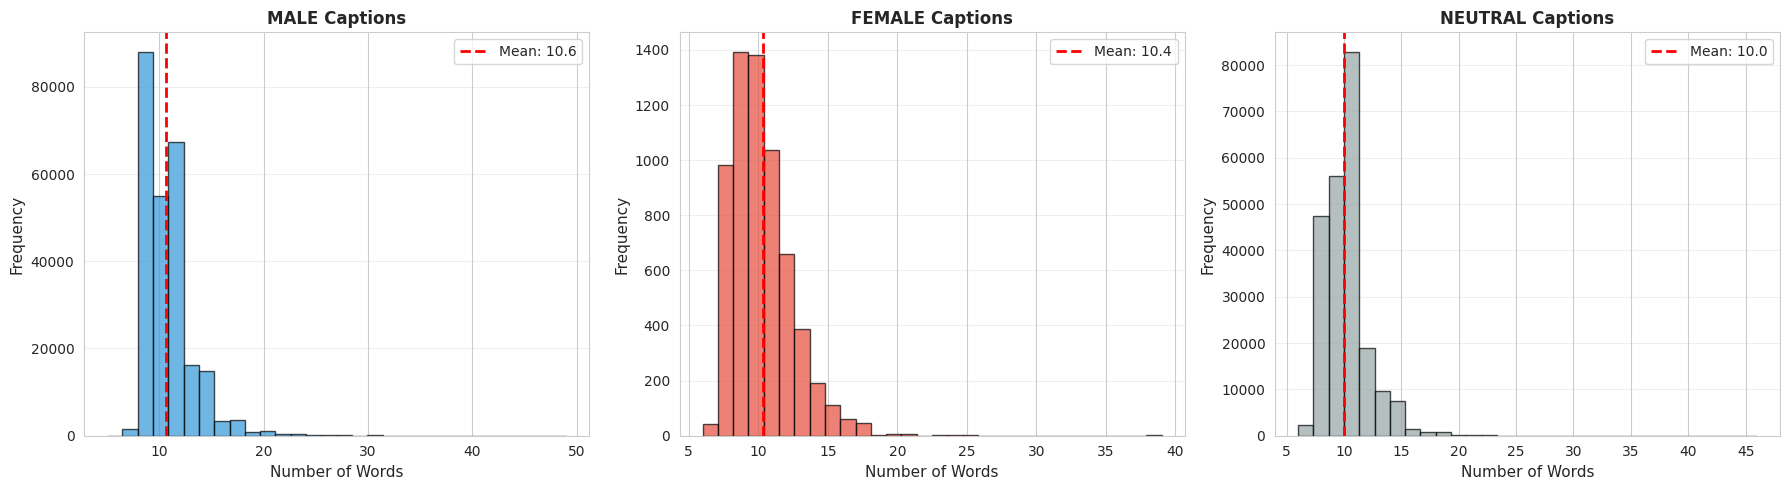

In [17]:
# Visualize caption length distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {'male': '#3498db', 'female': '#e74c3c', 'neutral': '#95a5a6'}

for idx, (gender, captions) in enumerate(caption_data.items()):
    if len(captions) > 0:
        word_counts = [c['word_count'] for c in captions]
        axes[idx].hist(word_counts, bins=30, color=colors[gender], alpha=0.7, edgecolor='black')
        axes[idx].axvline(np.mean(word_counts), color='red', linestyle='--', 
                         linewidth=2, label=f'Mean: {np.mean(word_counts):.1f}')
        axes[idx].set_xlabel('Number of Words', fontsize=11)
        axes[idx].set_ylabel('Frequency', fontsize=11)
        axes[idx].set_title(f'{gender.upper()} Captions', fontsize=12, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('caption_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Cell: Install Required Packages

!pip install transformers torch torchvision pillow nltk rouge-score
!pip install git+https://github.com/tylin/coco-caption.git

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/tylin/coco-caption.git to /tmp/pip-req-build-dxkk0ftk
  Running command git clone --filter=blob:none --quiet https://github.com/tylin/coco-caption.git /tmp/pip-req-build-dxkk0ftk
  Resolved https://github.com/tylin/coco-caption.git to commit 3a9afb2682141a03e1cdc02b0df6770d2c884f6f
ERROR: git+https://github.com/tylin/coco-caption.git does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [19]:
# Cell: Import Libraries and Setup

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# For BLEU score
import nltk
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

# For ROUGE score
from rouge_score import rouge_scorer

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

2025-11-27 15:07:05.697321: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-27 15:07:05.771047: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-27 15:07:08.752290: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Using device: cuda


In [20]:
# Cell: Load Pretrained BLIP Model

print("Loading pretrained BLIP model (trained on COCO)...")
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)
model.eval()
print("Model loaded successfully!")

# Print model info
print(f"\nModel: BLIP (Salesforce/blip-image-captioning-base)")
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Loading pretrained BLIP model (trained on COCO)...
Model loaded successfully!

Model: BLIP (Salesforce/blip-image-captioning-base)
Parameters: 224.0M


In [21]:
# Cell: Create Dataset for Evaluation

class COCOEvalDataset(Dataset):
    def __init__(self, coco_obj, coco_cap, img_dir, num_samples=None):
        self.coco_obj = coco_obj
        self.coco_cap = coco_cap
        self.img_dir = img_dir
        self.img_ids = list(coco_obj.imgs.keys())
        
        if num_samples:
            self.img_ids = self.img_ids[:num_samples]
    
    def __len__(self):
        return len(self.img_ids)
    
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco_obj.imgs[img_id]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Get all reference captions
        ann_ids = self.coco_cap.getAnnIds(imgIds=img_id)
        anns = self.coco_cap.loadAnns(ann_ids)
        captions = [ann['caption'] for ann in anns]
        
        return {
            'image': image,
            'image_id': img_id,
            'captions': captions
        }

# Create dataset (use validation set, limit to 1000 images for faster evaluation)
print("Creating evaluation dataset...")
eval_dataset = COCOEvalDataset(coco_val, coco_val_cap, VAL_IMG_DIR, num_samples=None)
print(f"Evaluation dataset size: {len(eval_dataset)} images")

Creating evaluation dataset...
Evaluation dataset size: 5000 images


In [22]:
# Cell: Generate Captions with BLIP (CORRECTED)

def generate_captions(model, processor, dataset, device, batch_size=32):
    """Generate captions for all images in the dataset"""
    results = []
    
    print("Generating captions...")
    
    # Process in batches manually
    for i in tqdm(range(0, len(dataset), batch_size)):
        batch_data = [dataset[j] for j in range(i, min(i + batch_size, len(dataset)))]
        
        images = [item['image'] for item in batch_data]
        img_ids = [item['image_id'] for item in batch_data]
        ref_captions = [item['captions'] for item in batch_data]
        
        with torch.no_grad():
            # Process images
            inputs = processor(images=images, return_tensors="pt").to(device)
            
            # Generate captions
            out = model.generate(**inputs, max_length=50, num_beams=3)
            generated_captions = processor.batch_decode(out, skip_special_tokens=True)
            
            # Store results
            for j in range(len(img_ids)):
                results.append({
                    'image_id': img_ids[j],
                    'generated_caption': generated_captions[j],
                    'reference_captions': ref_captions[j]
                })
    
    return results

# Generate captions
caption_results = generate_captions(model, processor, eval_dataset, device, batch_size=32)
print(f"\nGenerated {len(caption_results)} captions")

# Show some examples
print("\nExample Generated Captions:")
print("=" * 80)
for i in range(5):
    print(f"\nImage {i+1}:")
    print(f"Generated: {caption_results[i]['generated_caption']}")
    print(f"References:")
    for j, ref in enumerate(caption_results[i]['reference_captions'][:3]):
        print(f"  {j+1}. {ref}")
    print("-" * 80)

Generating captions...


  6%|▌         | 9/157 [00:10<02:57,  1.20s/it]


KeyboardInterrupt: 

In [ ]:
# Cell: Calculate BLEU-4 Score

def calculate_bleu_scores(results):
    """Calculate BLEU-4 scores"""
    references_list = []
    hypotheses_list = []
    individual_bleu_scores = []
    
    smooth = SmoothingFunction()
    
    for result in results:
        # Tokenize reference captions
        refs = [nltk.word_tokenize(cap.lower()) for cap in result['reference_captions']]
        references_list.append(refs)
        
        # Tokenize generated caption
        hyp = nltk.word_tokenize(result['generated_caption'].lower())
        hypotheses_list.append(hyp)
        
        # Calculate individual BLEU-4 score
        individual_bleu = sentence_bleu(refs, hyp, weights=(0, 0, 0, 1), 
                                       smoothing_function=smooth.method1)
        individual_bleu_scores.append(individual_bleu)
    
    # Calculate corpus-level BLEU-4
    corpus_bleu_4 = corpus_bleu(references_list, hypotheses_list, 
                                weights=(0, 0, 0, 1))
    
    # Also calculate BLEU-1, BLEU-2, BLEU-3 for completeness
    bleu_1 = corpus_bleu(references_list, hypotheses_list, weights=(1, 0, 0, 0))
    bleu_2 = corpus_bleu(references_list, hypotheses_list, weights=(0.5, 0.5, 0, 0))
    bleu_3 = corpus_bleu(references_list, hypotheses_list, weights=(0.33, 0.33, 0.33, 0))
    
    return {
        'bleu_1': bleu_1,
        'bleu_2': bleu_2,
        'bleu_3': bleu_3,
        'bleu_4': corpus_bleu_4,
        'individual_bleu_4': individual_bleu_scores
    }

print("Calculating BLEU scores...")
bleu_scores = calculate_bleu_scores(caption_results)

print("\n" + "=" * 60)
print("BLEU SCORES")
print("=" * 60)
print(f"BLEU-1: {bleu_scores['bleu_1']:.4f}")
print(f"BLEU-2: {bleu_scores['bleu_2']:.4f}")
print(f"BLEU-3: {bleu_scores['bleu_3']:.4f}")
print(f"BLEU-4: {bleu_scores['bleu_4']:.4f}")
print(f"Average Individual BLEU-4: {np.mean(bleu_scores['individual_bleu_4']):.4f}")
print("=" * 60)

In [ ]:
# Cell: Calculate ROUGE-L Score

def calculate_rouge_scores(results):
    """Calculate ROUGE-L scores"""
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    
    rouge_l_scores = []
    
    for result in results:
        generated = result['generated_caption']
        references = result['reference_captions']
        
        # Calculate ROUGE-L against each reference and take the maximum
        max_rouge_l = 0
        for ref in references:
            scores = scorer.score(ref, generated)
            rouge_l_f1 = scores['rougeL'].fmeasure
            max_rouge_l = max(max_rouge_l, rouge_l_f1)
        
        rouge_l_scores.append(max_rouge_l)
    
    return {
        'rouge_l_mean': np.mean(rouge_l_scores),
        'rouge_l_scores': rouge_l_scores
    }

print("Calculating ROUGE-L scores...")
rouge_scores = calculate_rouge_scores(caption_results)

print("\n" + "=" * 60)
print("ROUGE-L SCORES")
print("=" * 60)
print(f"ROUGE-L (mean): {rouge_scores['rouge_l_mean']:.4f}")
print(f"ROUGE-L (std):  {np.std(rouge_scores['rouge_l_scores']):.4f}")
print("=" * 60)

In [ ]:
# Cell: Define Fairness Metrics Based on Bias Analysis

class FairnessMetrics:
    """Calculate fairness metrics for generated captions"""
    
    def __init__(self, results):
        self.results = results
        self.male_terms = MALE_TERMS
        self.female_terms = FEMALE_TERMS
        
    def extract_gender_from_caption(self, caption):
        """Extract gender information from caption"""
        caption_lower = caption.lower()
        has_male = any(term in caption_lower for term in self.male_terms)
        has_female = any(term in caption_lower for term in self.female_terms)
        
        if has_male and has_female:
            return 'both'
        elif has_male:
            return 'male'
        elif has_female:
            return 'female'
        else:
            return 'neutral'
    
    def calculate_gender_distribution(self):
        """Calculate gender distribution in generated vs reference captions"""
        generated_genders = {'male': 0, 'female': 0, 'both': 0, 'neutral': 0}
        reference_genders = {'male': 0, 'female': 0, 'both': 0, 'neutral': 0}
        
        for result in self.results:
            # Generated caption gender
            gen_gender = self.extract_gender_from_caption(result['generated_caption'])
            generated_genders[gen_gender] += 1
            
            # Reference captions - use majority vote
            ref_gender_votes = [self.extract_gender_from_caption(cap) 
                               for cap in result['reference_captions']]
            ref_gender_counts = Counter(ref_gender_votes)
            if ref_gender_counts['male'] > ref_gender_counts['female']:
                majority_gender = 'male'
            elif ref_gender_counts['female'] > ref_gender_counts['male']:
                majority_gender = 'female'
            else:
                majority_gender = 'neutral'
            reference_genders[majority_gender] += 1
        
        return generated_genders, reference_genders
    
    def calculate_gender_amplification(self):
        """
        Calculate gender bias amplification ratio
        Ratio > 1 means model amplifies existing bias
        """
        gen_genders, ref_genders = self.calculate_gender_distribution()
        
        # Calculate male-to-female ratio
        gen_male = gen_genders['male'] + gen_genders['both']
        gen_female = gen_genders['female'] + gen_genders['both']
        ref_male = ref_genders['male'] + ref_genders['both']
        ref_female = ref_genders['female'] + ref_genders['both']
        
        gen_ratio = gen_male / gen_female if gen_female > 0 else float('inf')
        ref_ratio = ref_male / ref_female if ref_female > 0 else float('inf')
        
        amplification = gen_ratio / ref_ratio if ref_ratio > 0 else float('inf')
        
        return {
            'generated_ratio': gen_ratio,
            'reference_ratio': ref_ratio,
            'amplification_factor': amplification,
            'generated_distribution': gen_genders,
            'reference_distribution': ref_genders
        }
    
    def calculate_gender_accuracy(self):
        """
        Calculate how accurately the model predicts gender compared to references
        """
        correct = 0
        total = 0
        
        for result in self.results:
            gen_gender = self.extract_gender_from_caption(result['generated_caption'])
            
            # Reference gender - majority vote
            ref_gender_votes = [self.extract_gender_from_caption(cap) 
                               for cap in result['reference_captions']]
            ref_gender_counts = Counter(ref_gender_votes)
            
            if ref_gender_counts['male'] > ref_gender_counts['female']:
                ref_gender = 'male'
            elif ref_gender_counts['female'] > ref_gender_counts['male']:
                ref_gender = 'female'
            else:
                ref_gender = 'neutral'
            
            if gen_gender == ref_gender or (gen_gender in ['male', 'female'] and ref_gender == 'both'):
                correct += 1
            total += 1
        
        return correct / total if total > 0 else 0
    
    def analyze_object_gender_cooccurrence(self, coco_obj):
        """
        Analyze if model maintains/amplifies object-gender stereotypes
        Uses the top biased objects from earlier analysis
        """
        # Get category mapping
        categories = {cat_id: coco_obj.cats[cat_id]['name'] 
                     for cat_id in coco_obj.cats}
        
        object_gender_gen = defaultdict(lambda: {'male': 0, 'female': 0, 'neutral': 0})
        object_gender_ref = defaultdict(lambda: {'male': 0, 'female': 0, 'neutral': 0})
        
        for result in self.results:
            img_id = result['image_id']
            
            # Get objects in image
            ann_ids = coco_obj.getAnnIds(imgIds=img_id)
            anns = coco_obj.loadAnns(ann_ids)
            objects = set([categories[ann['category_id']] for ann in anns])
            
            # Generated caption gender
            gen_gender = self.extract_gender_from_caption(result['generated_caption'])
            if gen_gender != 'both':
                for obj in objects:
                    object_gender_gen[obj][gen_gender] += 1
            
            # Reference caption gender (majority)
            ref_gender_votes = [self.extract_gender_from_caption(cap) 
                               for cap in result['reference_captions']]
            ref_gender_counts = Counter(ref_gender_votes)
            if ref_gender_counts['male'] > ref_gender_counts['female']:
                ref_gender = 'male'
            elif ref_gender_counts['female'] > ref_gender_counts['male']:
                ref_gender = 'female'
            else:
                ref_gender = 'neutral'
            
            for obj in objects:
                object_gender_ref[obj][ref_gender] += 1
        
        return object_gender_gen, object_gender_ref
    
    def calculate_stereotype_score(self, object_gender_gen, object_gender_ref, 
                                   stereotyped_objects):
        """
        Calculate how much the model reinforces stereotypes for known biased objects
        Score closer to 1 means model maintains stereotypes
        Score > 1 means model amplifies stereotypes
        """
        stereotype_scores = {}
        
        for obj in stereotyped_objects:
            if obj in object_gender_gen and obj in object_gender_ref:
                gen_data = object_gender_gen[obj]
                ref_data = object_gender_ref[obj]
                
                gen_total = gen_data['male'] + gen_data['female']
                ref_total = ref_data['male'] + ref_data['female']
                
                if gen_total >= 5 and ref_total >= 5:  # Minimum threshold
                    gen_bias = abs(gen_data['male'] - gen_data['female']) / gen_total
                    ref_bias = abs(ref_data['male'] - ref_data['female']) / ref_total
                    
                    amplification = gen_bias / ref_bias if ref_bias > 0 else float('inf')
                    stereotype_scores[obj] = {
                        'generated_bias': gen_bias,
                        'reference_bias': ref_bias,
                        'amplification': amplification
                    }
        
        return stereotype_scores

print("Fairness metrics class defined successfully!")

In [ ]:
# Cell: Calculate All Fairness Metrics

print("Calculating fairness metrics...")
fairness = FairnessMetrics(caption_results)

# 1. Gender Distribution
gen_dist, ref_dist = fairness.calculate_gender_distribution()

print("\n" + "=" * 80)
print("FAIRNESS METRICS")
print("=" * 80)

print("\n1. GENDER DISTRIBUTION")
print("-" * 80)
print(f"{'Gender':<15} {'Generated':<15} {'Reference':<15} {'Difference':<15}")
print("-" * 80)
for gender in ['male', 'female', 'neutral', 'both']:
    diff = gen_dist[gender] - ref_dist[gender]
    print(f"{gender.capitalize():<15} {gen_dist[gender]:<15} {ref_dist[gender]:<15} {diff:+d}")

# 2. Gender Bias Amplification
amplification_data = fairness.calculate_gender_amplification()

print("\n2. GENDER BIAS AMPLIFICATION")
print("-" * 80)
print(f"Generated Male:Female Ratio:  {amplification_data['generated_ratio']:.2f}:1")
print(f"Reference Male:Female Ratio:  {amplification_data['reference_ratio']:.2f}:1")
print(f"Amplification Factor:         {amplification_data['amplification_factor']:.2f}x")
if amplification_data['amplification_factor'] > 1.1:
    print("⚠️  WARNING: Model AMPLIFIES gender bias by {:.1f}%".format(
        (amplification_data['amplification_factor'] - 1) * 100))
elif amplification_data['amplification_factor'] < 0.9:
    print("✓  Model REDUCES gender bias by {:.1f}%".format(
        (1 - amplification_data['amplification_factor']) * 100))
else:
    print("✓  Model maintains similar gender distribution as references")

# 3. Gender Prediction Accuracy
gender_accuracy = fairness.calculate_gender_accuracy()
print("\n3. GENDER PREDICTION ACCURACY")
print("-" * 80)
print(f"Accuracy: {gender_accuracy:.2%}")
print("(How often model's gender mentions match reference captions)")

# 4. Object-Gender Stereotype Analysis
print("\n4. OBJECT-GENDER STEREOTYPE ANALYSIS")
print("-" * 80)
print("Analyzing stereotyped objects...")

object_gender_gen, object_gender_ref = fairness.analyze_object_gender_cooccurrence(coco_val)

# Use known stereotyped objects from earlier analysis
stereotyped_male_objects = ['skateboard', 'surfboard', 'baseball', 'motorcycle', 'truck']
stereotyped_female_objects = ['handbag', 'hair', 'dress', 'umbrella']
all_stereotyped = stereotyped_male_objects + stereotyped_female_objects

stereotype_scores = fairness.calculate_stereotype_score(
    object_gender_gen, object_gender_ref, all_stereotyped
)

if len(stereotype_scores) > 0:
    print(f"\n{'Object':<15} {'Gen Bias':<12} {'Ref Bias':<12} {'Amplification':<15}")
    print("-" * 80)
    for obj, scores in sorted(stereotype_scores.items(), 
                             key=lambda x: x[1]['amplification'], 
                             reverse=True):
        amp_str = f"{scores['amplification']:.2f}x"
        if scores['amplification'] > 1.2:
            amp_str += " ⚠️ AMPLIFIED"
        elif scores['amplification'] < 0.8:
            amp_str += " ✓ REDUCED"
        
        print(f"{obj:<15} {scores['generated_bias']:<12.3f} "
              f"{scores['reference_bias']:<12.3f} {amp_str}")
    
    avg_amplification = np.mean([s['amplification'] for s in stereotype_scores.values()])
    print(f"\nAverage Stereotype Amplification: {avg_amplification:.2f}x")
else:
    print("Insufficient data for stereotype analysis on this sample")

print("\n" + "=" * 80)

In [ ]:
# Cell: Comprehensive Fairness Summary

def generate_fairness_summary(bleu_scores, rouge_scores, amplification_data, 
                             gender_accuracy, stereotype_scores):
    """Generate a comprehensive fairness summary"""
    
    summary = []
    summary.append("=" * 80)
    summary.append("BLIP MODEL EVALUATION SUMMARY")
    summary.append("=" * 80)
    summary.append("")
    
    summary.append("CAPTION QUALITY METRICS:")
    summary.append("-" * 80)
    summary.append(f"BLEU-4:  {bleu_scores['bleu_4']:.4f}")
    summary.append(f"ROUGE-L: {rouge_scores['rouge_l_mean']:.4f}")
    summary.append("")
    
    summary.append("FAIRNESS METRICS:")
    summary.append("-" * 80)
    summary.append(f"Gender Bias Amplification: {amplification_data['amplification_factor']:.2f}x")
    summary.append(f"Gender Prediction Accuracy: {gender_accuracy:.2%}")
    
    if len(stereotype_scores) > 0:
        avg_stereotype_amp = np.mean([s['amplification'] for s in stereotype_scores.values()])
        summary.append(f"Stereotype Amplification: {avg_stereotype_amp:.2f}x")
    summary.append("")
    
    summary.append("FAIRNESS ASSESSMENT:")
    summary.append("-" * 80)
    
    # Overall fairness grade
    issues = []
    if amplification_data['amplification_factor'] > 1.2:
        issues.append("⚠️  Significant gender bias amplification detected")
    if gender_accuracy < 0.7:
        issues.append("⚠️  Low gender prediction accuracy")
    if len(stereotype_scores) > 0:
        avg_stereotype_amp = np.mean([s['amplification'] for s in stereotype_scores.values()])
        if avg_stereotype_amp > 1.2:
            issues.append("⚠️  Model amplifies object-gender stereotypes")
    
    if len(issues) == 0:
        summary.append("✓ Model shows relatively fair behavior")
        summary.append("  - Gender bias is not significantly amplified")
        summary.append("  - Gender prediction aligns with references")
    else:
        summary.append("⚠️  FAIRNESS CONCERNS DETECTED:")
        for issue in issues:
            summary.append(f"  {issue}")
    
    summary.append("")
    summary.append("RECOMMENDATIONS:")
    summary.append("-" * 80)
    summary.append("1. Consider fine-tuning with bias mitigation techniques")
    summary.append("2. Use balanced datasets with counter-stereotypical examples")
    summary.append("3. Implement fairness constraints during training")
    summary.append("4. Regular auditing on gender-balanced test sets")
    summary.append("")
    summary.append("=" * 80)
    
    return "\n".join(summary)

fairness_summary = generate_fairness_summary(
    bleu_scores, rouge_scores, amplification_data, 
    gender_accuracy, stereotype_scores
)

print(fairness_summary)

# Save to file
with open('blip_evaluation_report.txt', 'w') as f:
    f.write(fairness_summary)
print("\nReport saved to: blip_evaluation_report.txt")

In [ ]:
# Cell: Visualize Fairness Metrics

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gender Distribution Comparison
ax1 = axes[0, 0]
genders = ['Male', 'Female', 'Neutral', 'Both']
gen_values = [gen_dist['male'], gen_dist['female'], gen_dist['neutral'], gen_dist['both']]
ref_values = [ref_dist['male'], ref_dist['female'], ref_dist['neutral'], ref_dist['both']]

x = np.arange(len(genders))
width = 0.35
ax1.bar(x - width/2, ref_values, width, label='Reference', color='#95a5a6', alpha=0.8)
ax1.bar(x + width/2, gen_values, width, label='Generated', color='#3498db', alpha=0.8)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Gender Distribution: Generated vs Reference', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(genders)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Amplification Factor
ax2 = axes[0, 1]
metrics = ['Gender\nBias', 'Stereotype\n(avg)']
if len(stereotype_scores) > 0:
    values = [amplification_data['amplification_factor'], 
              np.mean([s['amplification'] for s in stereotype_scores.values()])]
else:
    values = [amplification_data['amplification_factor'], 0]
    metrics = ['Gender\nBias']
    values = values[:1]

colors = ['#e74c3c' if v > 1.2 else '#27ae60' if v < 0.9 else '#f39c12' for v in values]
bars = ax2.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.axhline(y=1.0, color='black', linestyle='--', linewidth=2, label='No Amplification')
ax2.set_ylabel('Amplification Factor', fontsize=11)
ax2.set_title('Bias Amplification (>1 = Amplified, <1 = Reduced)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}x',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Performance Metrics
ax3 = axes[1, 0]
metric_names = ['BLEU-4', 'ROUGE-L', 'Gender\nAccuracy']
metric_values = [bleu_scores['bleu_4'], rouge_scores['rouge_l_mean'], gender_accuracy]
bars = ax3.bar(metric_names, metric_values, color=['#3498db', '#9b59b6', '#27ae60'], alpha=0.8)
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
ax3.set_ylim([0, 1.0])
ax3.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 4. Stereotype Amplification per Object
ax4 = axes[1, 1]
if len(stereotype_scores) > 0:
    sorted_objects = sorted(stereotype_scores.items(), 
                           key=lambda x: x[1]['amplification'], 
                           reverse=True)[:8]
    objects = [obj for obj, _ in sorted_objects]
    amplifications = [data['amplification'] for _, data in sorted_objects]
    colors = ['#e74c3c' if amp > 1.2 else '#27ae60' if amp < 0.8 else '#f39c12' 
              for amp in amplifications]
    
    ax4.barh(objects, amplifications, color=colors, alpha=0.8)
    ax4.axvline(x=1.0, color='black', linestyle='--', linewidth=2)
    ax4.set_xlabel('Amplification Factor', fontsize=11)
    ax4.set_title('Object-Gender Stereotype Amplification', fontsize=12, fontweight='bold')
    ax4.grid(axis='x', alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Insufficient data\nfor stereotype analysis', 
            ha='center', va='center', fontsize=12, transform=ax4.transAxes)
    ax4.set_title('Object-Gender Stereotype Amplification', fontsize=12, fontweight='bold')

plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/blip_fairness_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# print("\n✓ Visualization saved to: blip_fairness_evaluation.png")

In [ ]:
# Add diagnostic code
print("\n" + "=" * 80)
print("DIAGNOSTIC ANALYSIS")
print("=" * 80)

# Let's investigate what's actually happening
def diagnose_gender_behavior(caption_results):
    """Diagnose why gender amplification is so low"""
    
    # Count usage of gender-neutral vs gendered terms
    neutral_terms = ['person', 'people', 'someone', 'individual', 'rider', 'player']
    
    stats = {
        'total_captions': len(caption_results),
        'gen_mentions_people': 0,
        'gen_mentions_gender': 0,
        'gen_uses_neutral': 0,
        'ref_mentions_people': 0,
        'ref_mentions_gender': 0,
        'gen_no_people_but_ref_has': 0
    }
    
    for result in caption_results:
        gen_cap = result['generated_caption'].lower()
        ref_caps = [r.lower() for r in result['reference_captions']]
        
        # Check generated caption
        gen_has_person = any(term in gen_cap for term in neutral_terms + MALE_TERMS + FEMALE_TERMS)
        gen_has_gender = any(term in gen_cap for term in MALE_TERMS + FEMALE_TERMS)
        gen_has_neutral = any(term in gen_cap for term in neutral_terms)
        
        if gen_has_person:
            stats['gen_mentions_people'] += 1
        if gen_has_gender:
            stats['gen_mentions_gender'] += 1
        if gen_has_neutral:
            stats['gen_uses_neutral'] += 1
        
        # Check reference captions
        ref_has_person = any(any(term in ref for term in neutral_terms + MALE_TERMS + FEMALE_TERMS) 
                           for ref in ref_caps)
        ref_has_gender = any(any(term in ref for term in MALE_TERMS + FEMALE_TERMS) 
                           for ref in ref_caps)
        
        if ref_has_person:
            stats['ref_mentions_people'] += 1
        if ref_has_gender:
            stats['ref_mentions_gender'] += 1
        
        # Model misses people entirely
        if ref_has_person and not gen_has_person:
            stats['gen_no_people_but_ref_has'] += 1
    
    return stats

print("\nRunning diagnostic analysis...")
diag_stats = diagnose_gender_behavior(caption_results)

print("\nDiagnostic Results:")
print("-" * 80)
print(f"Total captions analyzed: {diag_stats['total_captions']}")
print(f"\nREFERENCE CAPTIONS:")
print(f"  Mention people: {diag_stats['ref_mentions_people']} ({diag_stats['ref_mentions_people']/diag_stats['total_captions']*100:.1f}%)")
print(f"  Mention gender: {diag_stats['ref_mentions_gender']} ({diag_stats['ref_mentions_gender']/diag_stats['total_captions']*100:.1f}%)")
print(f"\nGENERATED CAPTIONS:")
print(f"  Mention people: {diag_stats['gen_mentions_people']} ({diag_stats['gen_mentions_people']/diag_stats['total_captions']*100:.1f}%)")
print(f"  Mention gender: {diag_stats['gen_mentions_gender']} ({diag_stats['gen_mentions_gender']/diag_stats['total_captions']*100:.1f}%)")
print(f"  Use neutral terms: {diag_stats['gen_uses_neutral']} ({diag_stats['gen_uses_neutral']/diag_stats['total_captions']*100:.1f}%)")
print(f"\nMISSING PEOPLE:")
print(f"  Refs mention people but model doesn't: {diag_stats['gen_no_people_but_ref_has']} ({diag_stats['gen_no_people_but_ref_has']/diag_stats['total_captions']*100:.1f}%)")

print("\n" + "=" * 80)
print("INTERPRETATION:")
print("-" * 80)

if diag_stats['gen_uses_neutral'] > diag_stats['gen_mentions_gender']:
    print("✓ Model prefers GENDER-NEUTRAL language (person vs man/woman)")
    print("  This explains low amplification - model actively avoids gendered terms")
elif diag_stats['gen_no_people_but_ref_has'] > diag_stats['total_captions'] * 0.3:
    print("⚠️ Model FAILS TO DETECT people in many images")
    print("  This is problematic - captions are incomplete")
else:
    print("? Model behavior is unclear - needs further investigation")

print("=" * 80)

In [ ]:
# Cell: Install Additional Requirements for Fine-tuning

# !pip install accelerate datasets evaluate

In [23]:
# Cell: Import Libraries for Fine-tuning

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BlipProcessor, BlipForConditionalGeneration
from transformers import get_linear_schedule_with_warmup
from PIL import Image
import os
from tqdm import tqdm
import json
from collections import defaultdict
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Using device: cuda
GPU: NVIDIA RTX 5000 Ada Generation
Memory: 33.81 GB


In [24]:
# Cell: Download FairFace from Hugging Face (CORRECTED)

from datasets import load_dataset
import os
import pandas as pd

FAIRFACE_BASE_DIR = "/nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/datasets/fairface"
os.makedirs(FAIRFACE_BASE_DIR, exist_ok=True)

print("Downloading FairFace from Hugging Face...")
print("Using '0.25' config (face padding margin of 0.25)")

# Load the dataset with config
dataset = load_dataset("HuggingFaceM4/FairFace", "0.25", cache_dir=FAIRFACE_BASE_DIR)

print(f"\nTrain samples: {len(dataset['train'])}")
print(f"Validation samples: {len(dataset['validation'])}")

# Explore the structure
print("\nDataset structure:")
print(dataset)

print("\nExample from training set:")
example = dataset['train'][0]
print("Keys:", example.keys())
print("Age:", example.get('age'))
print("Gender:", example.get('gender'))
print("Race:", example.get('race'))
print("Image shape:", example['image'].size if hasattr(example['image'], 'size') else type(example['image']))

# Convert to pandas for easier handling
print("\nConverting to pandas DataFrames...")
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])

print("\nTraining DataFrame:")
print(train_df.head())
print("\nColumns:", train_df.columns.tolist())

print("\nGender distribution (train):")
print(train_df['gender'].value_counts())

print("\nRace distribution (train):")
print(train_df['race'].value_counts())

print("\nAge distribution (train):")
print(train_df['age'].value_counts())

# Save to CSV
print("\nSaving metadata to CSV...")
train_df[['age', 'gender', 'race']].to_csv(
    os.path.join(FAIRFACE_BASE_DIR, 'fairface_train_labels.csv'), 
    index=True
)
val_df[['age', 'gender', 'race']].to_csv(
    os.path.join(FAIRFACE_BASE_DIR, 'fairface_val_labels.csv'), 
    index=True
)

print("\n✓ FairFace dataset loaded successfully!")
print(f"Data cached at: {FAIRFACE_BASE_DIR}")

Using '0.25' config (face padding margin of 0.25)

Train samples: 86744
Validation samples: 10954

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['image', 'age', 'gender', 'race', 'service_test'],
        num_rows: 86744
    })
    validation: Dataset({
        features: ['image', 'age', 'gender', 'race', 'service_test'],
        num_rows: 10954
    })
})

Example from training set:
Keys: dict_keys(['image', 'age', 'gender', 'race', 'service_test'])
Age: 6
Gender: 0
Race: 0
Image shape: (224, 224)

Converting to pandas DataFrames...

Training DataFrame:
                                               image  age  gender  race  \
0  <PIL.JpegImagePlugin.JpegImageFile image mode=...    6       0     0   
1  <PIL.JpegImagePlugin.JpegImageFile image mode=...    4       1     1   
2  <PIL.JpegImagePlugin.JpegImageFile image mode=...    1       1     2   
3  <PIL.JpegImagePlugin.JpegImageFile image mode=...    3       1     1   
4  <PIL.JpegImagePlugin.JpegImageFile i

In [25]:
# Cell: Load Cached FairFace Dataset

from datasets import load_dataset

FAIRFACE_BASE_DIR = "/nfs/roberts/project/cpsc4710/cpsc4710_ag2995/project/datasets/fairface"

print("Loading cached FairFace dataset...")
dataset = load_dataset("HuggingFaceM4/FairFace", "0.25", cache_dir=FAIRFACE_BASE_DIR)

train_hf = dataset['train']
val_hf = dataset['validation']

print(f"Training samples: {len(train_hf):,}")
print(f"Validation samples: {len(val_hf):,}")

# Show example
print("\nExample sample:")
example = train_hf[0]
print(f"  Keys: {example.keys()}")
print(f"  Gender: {example['gender']}")
print(f"  Race: {example['race']}")
print(f"  Age: {example['age']}")
print(f"  Image type: {type(example['image'])}")

Loading cached FairFace dataset...
Training samples: 86,744
Validation samples: 10,954

Example sample:
  Keys: dict_keys(['image', 'age', 'gender', 'race', 'service_test'])
  Gender: 0
  Race: 0
  Age: 6
  Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>


In [30]:
# Cell: Create FairFace Dataset Class
from collections import Counter, defaultdict
class FairFaceHFDataset(Dataset):
    """FairFace Dataset from Hugging Face with caption generation"""
    
    def __init__(self, hf_dataset, processor, max_length=50, mode='train'):
        self.dataset = hf_dataset
        self.processor = processor
        self.max_length = max_length
        self.mode = mode
        
        # Print statistics
        genders = [item['gender'] for item in self.dataset]
        races = [item['race'] for item in self.dataset]
        ages = [item['age'] for item in self.dataset]
        
        print(f"\n{mode.upper()} Dataset Statistics:")
        print(f"  Total samples: {len(self.dataset):,}")
        
        print(f"\n  Gender distribution:")
        for gender, count in Counter(genders).items():
            print(f"    {gender}: {count:,} ({count/len(self.dataset)*100:.1f}%)")
        
        print(f"\n  Race distribution:")
        for race, count in Counter(races).most_common():
            print(f"    {race}: {count:,} ({count/len(self.dataset)*100:.1f}%)")
        
        print(f"\n  Age distribution:")
        for age, count in sorted(Counter(ages).items()):
            print(f"    {age}: {count:,} ({count/len(self.dataset)*100:.1f}%)")
    
    def generate_caption(self, age, gender, race):
        """Generate captions using ALL 3 available FairFace attributes"""
        
        age_map = {
            '0-2': 'infant', '3-9': 'child', '10-19': 'teenager',
            '20-29': 'young adult', '30-39': 'adult',
            '40-49': 'middle-aged adult', '50-59': 'middle-aged adult',
            '60-69': 'senior', 'more than 70': 'elderly person'
        }
        
        age_desc = age_map.get(age, 'adult')
        gender_noun = 'man' if gender == 'Male' else 'woman'
        
        # 5 captions with different attribute combinations
        captions = [
            # Full: Age + Race + Gender (ALL 3 attributes)
            f"a photo of a {age_desc} {race} {gender_noun}",
            
            # # Age + Gender only
            # f"a portrait of a {age_desc} {gender_noun}",
            
            # # Race + Gender only  
            # f"a close-up photo of a {race} {gender_noun}",
            
            # # Gender only
            # f"a headshot of a {gender_noun}",
            
            # # Neutral (no demographics)
            # f"a photo of a person"
        ]
        
        return captions
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        item = self.dataset[idx]
        
        # Get image (already a PIL Image from HF dataset)
        image = item['image']
        if image.mode != 'RGB':
            image = image.convert('RGB')
        
        # Get attributes
        age = item['age']
        gender = item['gender']
        race = item['race']
        
        # Generate captions
        captions = self.generate_caption(age, gender, race)
        
        # Pick one random caption for training
        caption = np.random.choice(captions)
        
        # Process image
        encoding = self.processor(
            images=image,
            return_tensors="pt"
        )
        
        # Process text
        text_encoding = self.processor.tokenizer(
            caption,
            padding="max_length",
            max_length=self.max_length,
            truncation=True,
            return_tensors="pt"
        )
        
        return {
            'pixel_values': encoding['pixel_values'].squeeze(0),
            'input_ids': text_encoding['input_ids'].squeeze(0),
            'attention_mask': text_encoding['attention_mask'].squeeze(0),
            'gender': gender,
            'race': race,
            'age': age,
            'captions': captions  # Store all captions for eval
        }

print("Creating datasets...")
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

train_dataset = FairFaceHFDataset(train_hf, processor, mode='train')
val_dataset = FairFaceHFDataset(val_hf, processor, mode='val')

Creating datasets...

TRAIN Dataset Statistics:
  Total samples: 86,744

  Gender distribution:
    0: 45,986 (53.0%)
    1: 40,758 (47.0%)

  Race distribution:
    3: 16,527 (19.1%)
    5: 13,367 (15.4%)
    1: 12,319 (14.2%)
    0: 12,287 (14.2%)
    2: 12,233 (14.1%)
    6: 10,795 (12.4%)
    4: 9,216 (10.6%)

  Age distribution:
    0: 1,792 (2.1%)
    1: 10,408 (12.0%)
    2: 9,103 (10.5%)
    3: 25,598 (29.5%)
    4: 19,250 (22.2%)
    5: 10,744 (12.4%)
    6: 6,228 (7.2%)
    7: 2,779 (3.2%)
    8: 842 (1.0%)

VAL Dataset Statistics:
  Total samples: 10,954

  Gender distribution:
    0: 5,792 (52.9%)
    1: 5,162 (47.1%)

  Race distribution:
    3: 2,085 (19.0%)
    5: 1,623 (14.8%)
    2: 1,556 (14.2%)
    0: 1,550 (14.2%)
    1: 1,516 (13.8%)
    6: 1,415 (12.9%)
    4: 1,209 (11.0%)

  Age distribution:
    0: 199 (1.8%)
    1: 1,356 (12.4%)
    2: 1,181 (10.8%)
    3: 3,300 (30.1%)
    4: 2,330 (21.3%)
    5: 1,353 (12.4%)
    6: 796 (7.3%)
    7: 321 (2.9%)
    8: 118 (1

In [31]:
# Cell: Setup Training Configuration

# Load model
print("Loading BLIP model...")
model = BlipForConditionalGeneration.from_pretrained(
    "Salesforce/blip-image-captioning-base"
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

# Training hyperparameters
BATCH_SIZE = 32  # FairFace images are small, can use larger batch
EPOCHS = 5
LEARNING_RATE = 5e-5
WARMUP_STEPS = 500
GRADIENT_ACCUMULATION_STEPS = 1
MAX_GRAD_NORM = 1.0

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps
)

print(f"\nTraining Configuration:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Total steps: {total_steps:,}")
print(f"  Steps per epoch: {len(train_loader):,}")
print(f"  Warmup steps: {WARMUP_STEPS}")

Loading BLIP model...
Model parameters: 224.0M

Training Configuration:
  Batch size: 32
  Epochs: 5
  Learning rate: 5e-05
  Total steps: 13,555
  Steps per epoch: 2,711
  Warmup steps: 500


In [32]:
# Cell: Training Functions

def train_epoch(model, dataloader, optimizer, scheduler, device, epoch):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc=f"Epoch {epoch+1}")
    
    optimizer.zero_grad()
    
    for step, batch in enumerate(progress_bar):
        # Move to device
        pixel_values = batch['pixel_values'].to(device)
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        # Create labels
        labels = input_ids.clone()
        labels[labels == processor.tokenizer.pad_token_id] = -100
        
        # Forward pass
        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )
        
        loss = outputs.loss
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
        total_loss += loss.item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'avg_loss': f'{total_loss/(step+1):.4f}',
            'lr': f'{scheduler.get_last_lr()[0]:.2e}'
        })
    
    return total_loss / len(dataloader)

def validate(model, dataloader, device):
    """Validate the model"""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            pixel_values = batch['pixel_values'].to(device)
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            labels = input_ids.clone()
            labels[labels == processor.tokenizer.pad_token_id] = -100
            
            outputs = model(
                pixel_values=pixel_values,
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            total_loss += outputs.loss.item()
    
    return total_loss / len(dataloader)

In [33]:
# Cell: Training Loop

print("\nStarting training on FairFace dataset...")
print("=" * 80)

best_val_loss = float('inf')
training_history = {
    'train_loss': [],
    'val_loss': []
}

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 80)
    
    # Train
    train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, epoch)
    
    # Validate
    val_loss = validate(model, val_loader, device)
    
    # Save history
    training_history['train_loss'].append(train_loss)
    training_history['val_loss'].append(val_loss)
    
    print(f"\nEpoch {epoch + 1} Summary:")
    print(f"  Training Loss:   {train_loss:.4f}")
    print(f"  Validation Loss: {val_loss:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        print(f"  ✓ New best model! Saving...")
        model.save_pretrained("checkpoints/blip-finetuned-fairface")
        processor.save_pretrained("checkpoints/blip-finetuned-fairface")
    
    print("-" * 80)

print("\n" + "=" * 80)
print("Training completed!")
print(f"Best validation loss: {best_val_loss:.4f}")
print("=" * 80)

# Save training history
with open('checkpoints/training_history.json', 'w') as f:
    json.dump(training_history, f)


Starting training on FairFace dataset...

Epoch 1/5
--------------------------------------------------------------------------------


Epoch 1:   3%|▎         | 83/2711 [01:11<37:58,  1.15it/s, loss=0.2331, avg_loss=1.5031, lr=8.30e-06] 


KeyboardInterrupt: 